<a href="https://colab.research.google.com/github/PURNACHANDRARAOPARCHURI/Quora-Question-Pairs-Matching/blob/main/NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
df=pd.read_csv("/content/train.csv")

In [2]:
df.shape

(404290, 6)

In [3]:
df.head()

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0


In [4]:
df['is_duplicate'].value_counts()

,count
is_duplicate,
0,255027
1,149263


In [5]:
new_df=df.sample(40000,random_state=4)

In [6]:
new_df.isnull().sum()

,0
id,0
qid1,0
qid2,0
question1,0
question2,0
is_duplicate,0


In [7]:
new_df.duplicated().sum()

np.int64(0)

In [8]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate
198127,198127,570,140055,Where can I buy best quality customized cupcak...,"Where can I buy delicious, fresh & hand made c...",1
338078,338078,361056,465606,How can you determine the valency of hydrogen?,How is valency of phosphorus determined?,0
246894,246894,344397,360022,How can I inspire you?,How can I inspire myself?,0
79011,79011,134619,1121,What are the must places to visit in Kerala (6...,What are the best places to visit in Kerala fo...,1
150179,150179,236419,236420,How do you qualify for gastric bypass surgery?,What are the positive and negative side effect...,0


In [9]:
new_df=new_df.dropna()

In [10]:
new_df.isnull().sum()
questions=new_df[["question1","question2"]]

In [11]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=1500)
que_df=list(new_df["question1"])+list(new_df["question2"])
que_df[0:6]

['Where can I buy best quality customized cupcakes in Gold Coast?',
 'How can you determine the valency of hydrogen?',
 'How can I inspire you?',
 'What are the must places to visit in Kerala (6-7 days)?',
 'How do you qualify for gastric bypass surgery?',
 'Why do you like Candy Crush Saga?']

In [12]:
q1_arr,q2_arr=np.vsplit(cv.fit_transform(que_df).toarray(),2)

In [13]:
temp_df1=pd.DataFrame(q1_arr,index=questions.index)
temp_df2=pd.DataFrame(q2_arr,index=questions.index)
temp_df1.head()

,0,1,2,3,4,5,6,7,8,9,...,1490,1491,1492,1493,1494,1495,1496,1497,1498,1499
198127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
338078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
246894,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
79011,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150179,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0


In [14]:
tem_df=pd.concat([temp_df1,temp_df2],axis=1)

In [15]:
tem_df["is_duplicate"]=new_df["is_duplicate"]
tem_df.head()

,0,1,2,3,4,5,6,7,8,9,...,1491,1492,1493,1494,1495,1496,1497,1498,1499,is_duplicate
198127,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
338078,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
246894,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
79011,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
150179,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(tem_df.iloc[:,0:-1].values,tem_df.iloc[:,-1].values,test_size=0.2,random_state=42)

In [17]:
new_df.head()
new_df["q1_len"]=new_df["question1"].str.len()
new_df["q2_len"]=new_df["question2"].str.len()
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len
198127,198127,570,140055,Where can I buy best quality customized cupcak...,"Where can I buy delicious, fresh & hand made c...",1,63,77
338078,338078,361056,465606,How can you determine the valency of hydrogen?,How is valency of phosphorus determined?,0,46,40
246894,246894,344397,360022,How can I inspire you?,How can I inspire myself?,0,22,25
79011,79011,134619,1121,What are the must places to visit in Kerala (6...,What are the best places to visit in Kerala fo...,1,55,65
150179,150179,236419,236420,How do you qualify for gastric bypass surgery?,What are the positive and negative side effect...,0,46,93


In [18]:
new_df["q1_words"]=new_df["question1"].apply(lambda x:len(x.split(" ")))
new_df["q2_words"]=new_df["question2"].apply(lambda x:len(x.split(" ")))
new_df.head()



,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words
198127,198127,570,140055,Where can I buy best quality customized cupcak...,"Where can I buy delicious, fresh & hand made c...",1,63,77,11,15
338078,338078,361056,465606,How can you determine the valency of hydrogen?,How is valency of phosphorus determined?,0,46,40,8,6
246894,246894,344397,360022,How can I inspire you?,How can I inspire myself?,0,22,25,5,5
79011,79011,134619,1121,What are the must places to visit in Kerala (6...,What are the best places to visit in Kerala fo...,1,55,65,11,12
150179,150179,236419,236420,How do you qualify for gastric bypass surgery?,What are the positive and negative side effect...,0,46,93,8,16


In [19]:
def commonwords(row):
  w1=set(map(lambda word:word.lower().strip(),row['question1'].split(" ")))
  w2=set(map(lambda word:word.lower().strip(),row['question2'].split(" ")))
  return len(w1&w2)

In [20]:
new_df["common_words"]=new_df.apply(commonwords,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words
198127,198127,570,140055,Where can I buy best quality customized cupcak...,"Where can I buy delicious, fresh & hand made c...",1,63,77,11,15,6
338078,338078,361056,465606,How can you determine the valency of hydrogen?,How is valency of phosphorus determined?,0,46,40,8,6,3
246894,246894,344397,360022,How can I inspire you?,How can I inspire myself?,0,22,25,5,5,4
79011,79011,134619,1121,What are the must places to visit in Kerala (6...,What are the best places to visit in Kerala fo...,1,55,65,11,12,8
150179,150179,236419,236420,How do you qualify for gastric bypass surgery?,What are the positive and negative side effect...,0,46,93,8,16,3


In [21]:
def totalwords(row):
  w1=set(map(lambda word:word.lower().strip(),row['question1'].split(" ")))
  w2=set(map(lambda word:word.lower().strip(),row['question2'].split(" ")))
  return len(w1)+len(w2)


In [22]:
new_df["totalwords"]=new_df.apply(totalwords,axis=1)
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,totalwords
198127,198127,570,140055,Where can I buy best quality customized cupcak...,"Where can I buy delicious, fresh & hand made c...",1,63,77,11,15,6,26
338078,338078,361056,465606,How can you determine the valency of hydrogen?,How is valency of phosphorus determined?,0,46,40,8,6,3,14
246894,246894,344397,360022,How can I inspire you?,How can I inspire myself?,0,22,25,5,5,4,10
79011,79011,134619,1121,What are the must places to visit in Kerala (6...,What are the best places to visit in Kerala fo...,1,55,65,11,12,8,23
150179,150179,236419,236420,How do you qualify for gastric bypass surgery?,What are the positive and negative side effect...,0,46,93,8,16,3,24


In [23]:
new_df["word_ratio"]=new_df["common_words"]/new_df["totalwords"]
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,totalwords,word_ratio
198127,198127,570,140055,Where can I buy best quality customized cupcak...,"Where can I buy delicious, fresh & hand made c...",1,63,77,11,15,6,26,0.230769
338078,338078,361056,465606,How can you determine the valency of hydrogen?,How is valency of phosphorus determined?,0,46,40,8,6,3,14,0.214286
246894,246894,344397,360022,How can I inspire you?,How can I inspire myself?,0,22,25,5,5,4,10,0.400000
79011,79011,134619,1121,What are the must places to visit in Kerala (6...,What are the best places to visit in Kerala fo...,1,55,65,11,12,8,23,0.347826
150179,150179,236419,236420,How do you qualify for gastric bypass surgery?,What are the positive and negative side effect...,0,46,93,8,16,3,24,0.125000


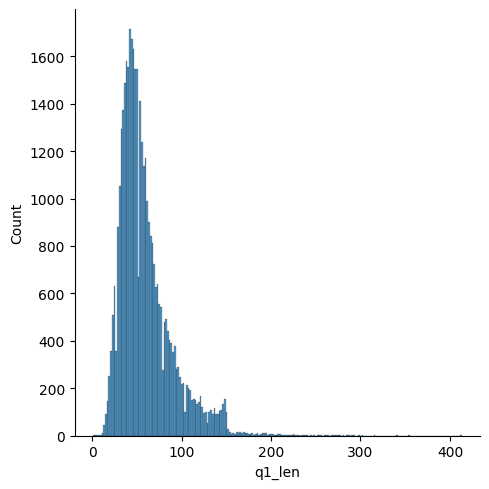

In [24]:
import seaborn as sns
sns.displot(new_df["q1_len"])

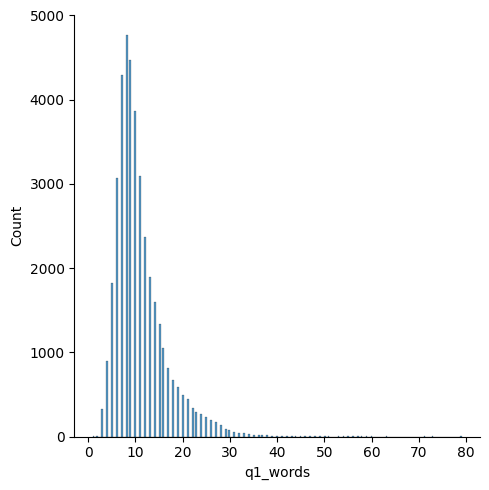

In [25]:
sns.displot(new_df["q1_words"])

In [26]:
new_df.head()

,id,qid1,qid2,question1,question2,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,totalwords,word_ratio
198127,198127,570,140055,Where can I buy best quality customized cupcak...,"Where can I buy delicious, fresh & hand made c...",1,63,77,11,15,6,26,0.230769
338078,338078,361056,465606,How can you determine the valency of hydrogen?,How is valency of phosphorus determined?,0,46,40,8,6,3,14,0.214286
246894,246894,344397,360022,How can I inspire you?,How can I inspire myself?,0,22,25,5,5,4,10,0.400000
79011,79011,134619,1121,What are the must places to visit in Kerala (6...,What are the best places to visit in Kerala fo...,1,55,65,11,12,8,23,0.347826
150179,150179,236419,236420,How do you qualify for gastric bypass surgery?,What are the positive and negative side effect...,0,46,93,8,16,3,24,0.125000


In [27]:
final_df=new_df.drop(["id","qid1","qid2","question1","question2"],axis=1)
final_df.head()

,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,totalwords,word_ratio
198127,1,63,77,11,15,6,26,0.230769
338078,0,46,40,8,6,3,14,0.214286
246894,0,22,25,5,5,4,10,0.400000
79011,1,55,65,11,12,8,23,0.347826
150179,0,46,93,8,16,3,24,0.125000


In [28]:
from sklearn.feature_extraction.text import CountVectorizer
cv=CountVectorizer(max_features=2000)
questions=list(new_df["question1"])+list(new_df["question2"])
q1_arr,q2_arr=np.vsplit(cv.fit_transform(questions).toarray(),2)

q_df=new_df[["question1","question2"]]

In [29]:
temp_df1=pd.DataFrame(q1_arr,index=q_df.index)
temp_df2=pd.DataFrame(q2_arr,index=q_df.index)
temp_df=pd.concat([temp_df1,temp_df2],axis=1)

In [30]:
import pandas as pd
final1_df=pd.concat([final_df,temp_df],axis=1)
final1_df.head()

,is_duplicate,q1_len,q2_len,q1_words,q2_words,common_words,totalwords,word_ratio,0,1,...,1990,1991,1992,1993,1994,1995,1996,1997,1998,1999
198127,1,63,77,11,15,6,26,0.230769,0,0,...,0,0,0,0,0,0,0,0,0,0
338078,0,46,40,8,6,3,14,0.214286,0,0,...,0,0,0,0,0,0,0,0,0,0
246894,0,22,25,5,5,4,10,0.400000,0,0,...,0,0,0,0,0,0,0,0,0,0
79011,1,55,65,11,12,8,23,0.347826,0,0,...,0,0,0,0,0,0,0,0,0,0
150179,0,46,93,8,16,3,24,0.125000,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
x_train,x_test,y_train,y_test=train_test_split(final1_df.iloc[:,1:].values,final1_df.iloc[:,0].values,test_size=0.2,random_state=42)
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(n_estimators=70,max_depth=10,n_jobs=-1)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
accuracy_score(y_pred,y_test)


0.662125

In [32]:
from xgboost import XGBClassifier
xb=XGBClassifier()
xb.fit(x_train,y_train)
y_pred=xb.predict(x_test)
accuracy_score(y_pred,y_test)


0.771375